<a href="https://colab.research.google.com/github/danielassaqovi/Daniel-PCVK_Ganjil_2026/blob/main/pertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**D2 — Pengenalan Python untuk Membaca dan Menampilkan Image**

Pengenalan macam-macam library (Numpy, pandas, cv2, skimage, PIL, matplotlib).

**Langkah 1 — Import Library**

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

**Langkah 2 — Baca Image dari URLs**

Catatan: placekitten.com di modul sudah tidak aktif, diganti picsum.photos (fungsinya sama, sumber foto publik lain).

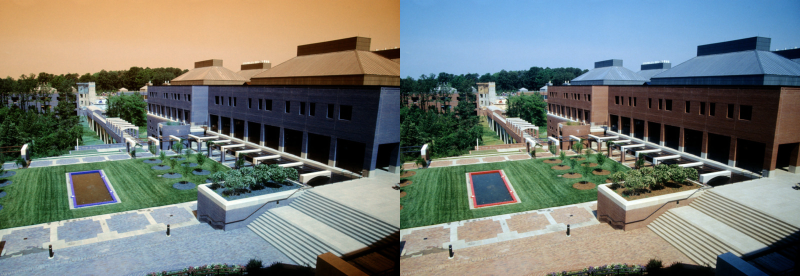

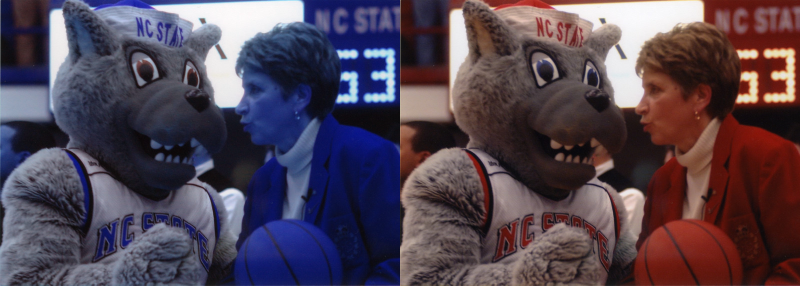

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    # "https://placekitten.com/800/571",
]

# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)  # read image
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)  # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)  # convert color to RGB
    final_frame = cv.hconcat((image, image_2))  # concatenate image
    cv2_imshow(final_frame)  # show image
    print("\n")

**Langkah 3 — Melihat Ukuran File Image**

resolusi image: tinggi x lebar  286  x  400


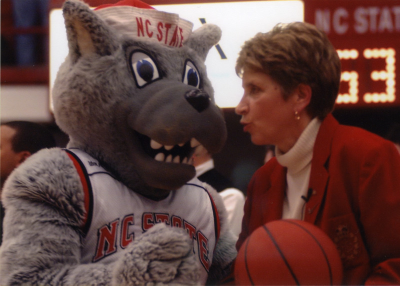

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar ", tinggi," x ", lebar)
cv2_imshow(image_2)

**Langkah 4 — Akses Pixel: Garis Horizontal Putih di Tengah Image**

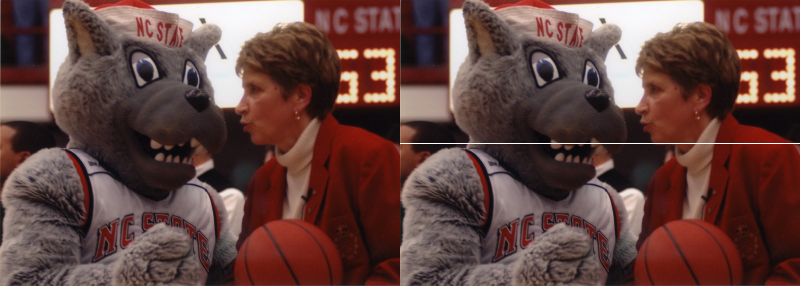

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
#membuat garis horizontal ditengah image
for y in range (lebar):
  image_3[int((tinggi)/2),y] = [255,255,255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

**PERTANYAAN PRAKTIKUM D2**
1. Mengapa eksekusi kode Python pada modul ini dilakukan menggunakan Google Colab?

Google Colab menyediakan environment Python siap pakai di cloud (sudah terpasang numpy, pandas, cv2, dll tanpa instalasi manual), gratis akses GPU/TPU, mudah dibagikan/dikolaborasikan lewat link, dan terintegrasi langsung dengan Google Drive serta GitHub sehingga file citra dan notebook mudah diakses dan disimpan tanpa tergantung environment lokal masing-masing mahasiswa yang bisa berbeda-beda (versi Python, OS, dependency).

2. Kegunaan setiap library pada praktikum langkah ke-delapan? Apakah semua library harus digunakan?

numpy — manipulasi array/matriks, dasar representasi citra sebagai array piksel, operasi numerik (aljabar linear, dsb).
pandas — manipulasi dan analisis data tabular (dipakai bila ada data pendukung berupa tabel, mis. label/metadata citra).
cv2 (OpenCV) — operasi computer vision: membaca, menampilkan, mengubah ukuran, mengonversi warna, menggambar bentuk pada citra.
skimage (scikit-image) — pemrosesan citra tingkat tinggi, termasuk io.imread untuk membaca citra dari file/URL dan transform untuk transformasi geometris.
matplotlib — menampilkan citra dalam bentuk plot lengkap dengan sumbu (berguna melihat ukuran piksel), serta visualisasi grafik.
Tidak semua wajib dipakai di setiap sesi — pandas misalnya baru relevan bila mengolah data tabular. Untuk sekadar baca-tampilkan-olah citra, inti yang dipakai adalah numpy, cv2, dan matplotlib/skimage.

3. image = cv.resize(image, (0,0), fx=0.5, fy=0.5) — kegunaan dan pengaruh jika tidak dilakukan?

Baris ini memperkecil ukuran citra menjadi setengah dari ukuran asli (fx/fy = skala lebar/tinggi), tanpa menentukan ukuran piksel absolut (karena target size (0,0) diabaikan saat fx,fy diisi). Kegunaannya menghemat memori dan mempercepat proses (concat/tampilkan) terutama untuk citra beresolusi besar. Jika tidak dilakukan, citra tetap dalam ukuran asli — proses jadi lebih berat, dan saat digabung (hconcat) dengan citra hasil konversi warna, kedua citra tetap harus berukuran sama sehingga tidak masalah selama keduanya tidak di-resize, hanya saja hasil tampilan jauh lebih besar dan boros resource.

4. Kegunaan kode [255,255,255]?

[255,255,255] adalah nilai piksel RGB (Red, Green, Blue) maksimum di setiap channel pada citra 8-bit, yang menghasilkan warna putih. Baris image_3[int((tinggi)/2), y] = [255,255,255] mengubah nilai piksel pada baris tengah citra (semua channel warna) menjadi putih, sehingga membentuk garis horizontal putih di tengah citra.

5. Keterkaitan pixel dan resolusi citra (tinggi/rendah)?

Pixel adalah satuan terkecil penyusun citra digital, masing-masing menyimpan nilai warna/intensitas. Resolusi adalah jumlah total pixel yang menyusun citra (lebar × tinggi). Semakin tinggi resolusi, semakin banyak pixel yang membentuk citra sehingga detail gambar lebih halus dan tajam, namun ukuran data (memori/penyimpanan) dan waktu pemrosesan juga meningkat. Sebaliknya, resolusi rendah berarti sedikit pixel — citra lebih kasar/blur (kurang detail) tetapi lebih ringan diproses dan disimpan.

**TUGAS PRAKTIKUM D2**


1. Lakukan langkah-langkah praktikum seperti diatas
2. Buat garis vertikal dan garis menyilang diagonal pada image keluaran

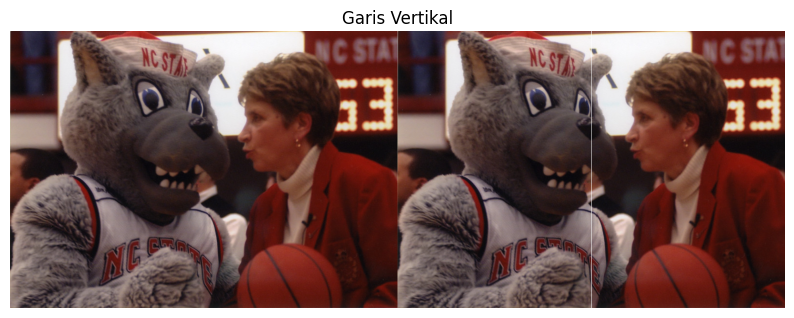

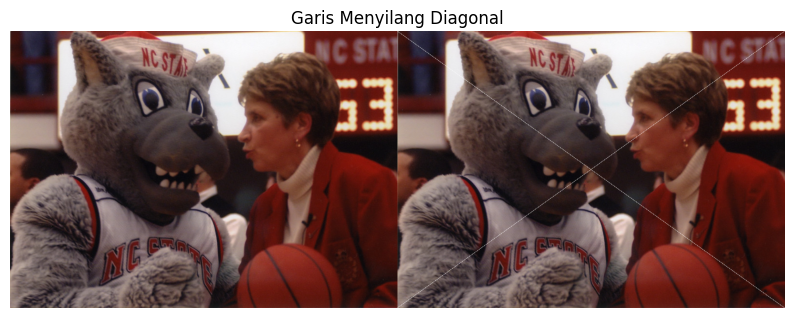

In [ ]:
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

for url in urls:
    try:
        # Unduh gambar dengan headers untuk menghindari blokir HTTP 521
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        image = io.imread(sys_io.BytesIO(response.content))

        h, w, _ = image.shape

        # ==============================
        # 1. Garis Vertikal Saja
        # ==============================
        img_vertical = image.copy()
        mid_col = w // 2

        for r in range(h):
            img_vertical[r, mid_col] = [255, 255, 255]

        frame_vertikal = np.hstack((image, img_vertical))

        plt.figure(figsize=(10, 5))
        plt.imshow(frame_vertikal)
        plt.title("Garis Vertikal")
        plt.axis("off")
        plt.show()

        # ==============================
        # 2. Garis Diagonal Saja
        # ==============================
        img_diagonal = image.copy()

        for r in range(h):
            c1 = int(r * (w - 1) / (h - 1))          # Kiri atas ke kanan bawah
            c2 = int((h - 1 - r) * (w - 1) / (h - 1))  # Kanan atas ke kiri bawah
            img_diagonal[r, c1] = [255, 255, 255]
            img_diagonal[r, c2] = [255, 255, 255]

        frame_diagonal = np.hstack((image, img_diagonal))

        plt.figure(figsize=(10, 5))
        plt.imshow(frame_diagonal)
        plt.title("Garis Menyilang Diagonal")
        plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Gagal memproses gambar dari {url}: {e}\n")

3. Buat garis horisontal berwarna putih dibagian tengah gambar dengan
panjang tertentu

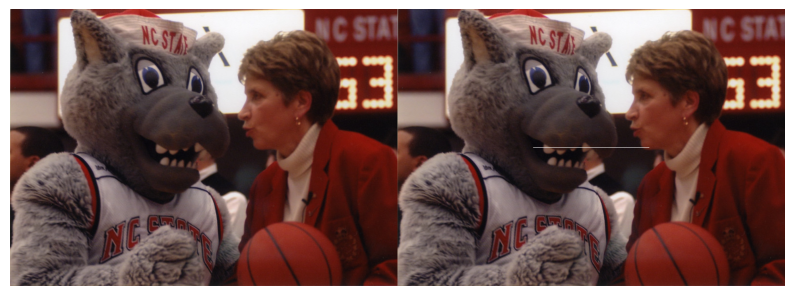

In [ ]:
url = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    image = io.imread(sys_io.BytesIO(response.content))

    h, w, _ = image.shape
    img_horizontal = image.copy()

    # Titik tengah vertikal
    mid_row = h // 2

    # Panjang garis: 40% dari lebar gambar
    line_length = int(w * 0.3)
    start_col = (w - line_length) // 2
    end_col = start_col + line_length

    # Gambar garis horizontal putih di tengah
    for c in range(start_col, end_col):
        img_horizontal[mid_row, c] = [255, 255, 255]

    # Gabungkan berdampingan
    frame_horizontal = np.hstack((image, img_horizontal))

    plt.figure(figsize=(10, 5))
    plt.imshow(frame_horizontal)
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Gagal memproses gambar: {e}")

4. Buat kotak menggunakan kumpulan pixel warna putih di sembarang tempat
dalam gambar

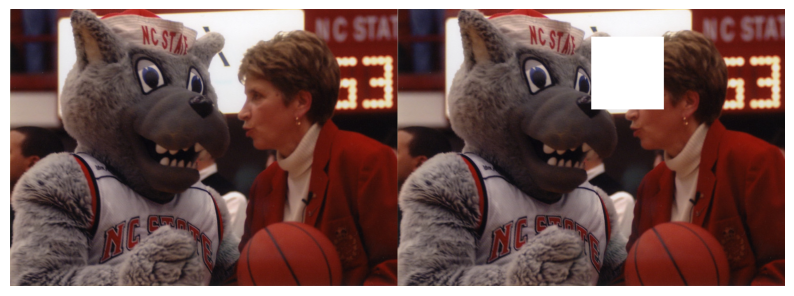

In [ ]:
url = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    image = io.imread(sys_io.BytesIO(response.content))

    h, w, _ = image.shape
    img_box = image.copy()

    # Ukuran kotak (misal: panjang sisi 150 pixel)
    box_size = 150

    # Titik awal koordinat kotak (bisa disesuaikan atau diacak)
    start_row = int(h * 0.10)
    start_col = int(w * 0.50)

    # Mengisi area kotak dengan kumpulan pixel warna putih [255, 255, 255]
    for r in range(start_row, start_row + box_size):
        for c in range(start_col, start_col + box_size):
            img_box[r, c] = [255, 255, 255]

    # Gabungkan gambar asli dan gambar dengan kotak putih secara berdampingan
    frame_box = np.hstack((image, img_box))

    plt.figure(figsize=(10, 5))
    plt.imshow(frame_box)
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Gagal memproses gambar: {e}")

**D3 — Pengolahan Citra Dasar & Channel Warna pada OpenCV**

1. Koneksi Google Drive (jalankan hanya di Google Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload() #akan muncul dialog pilih file

Saving contoh KTM.png to contoh KTM.png


2. Menyiapkan & Menampilkan Gambar

    Ganti IMG_PATH dengan path file citra Anda di Google Drive, mis. /content/drive/MyDrive/PCVK/contoh KTM.png. Sebagai default, sel di bawah membuat citra sampel lokal (sample_image.jpg) memakai skimage.data.chelsea() supaya notebook tetap bisa dijalankan tanpa file pribadi

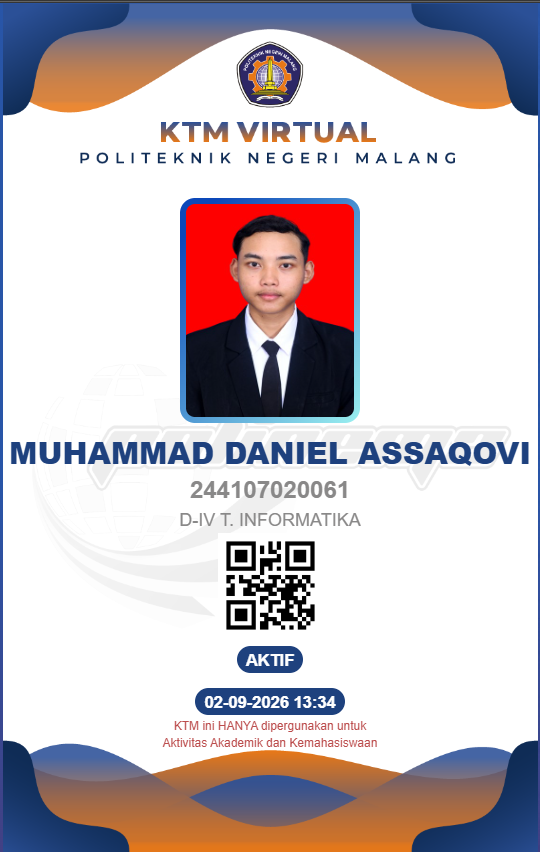

Resolusi gambar: 540 x 852


In [ ]:
# import cv2
from google.colab.patches import cv2_imshow # for image display

img = cv2.imread("contoh KTM.png")
cv2_imshow(img)

print("Resolusi gambar:", img.shape[1], "x", img.shape[0])


Menampilkan Gambar (Image Plotting) dengan Matplotlib

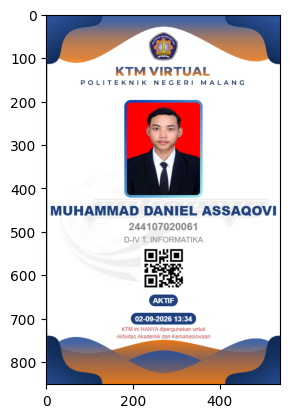

In [ ]:
#Menampilkan gambar
#import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png")
plt.imshow(img2) #format warna BGR\


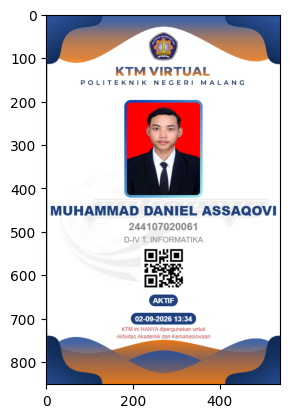

In [ ]:
# import cv2
# import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) #format warna RGB
plt.show()

3. Menampilkan Citra Grayscale

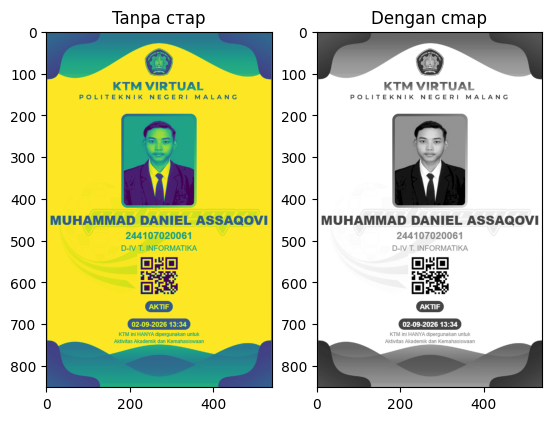

In [ ]:
img_gray = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png", cv2.IMREAD_GRAYSCALE)
# Tanpa стар
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa стар")
# Dengan cтар
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")
plt.show()

Jika ingin mengganti warna yang lain, tinggal mengganti cmap sesuai keinginan, contohnya untuk ditampilkan colormap dengan warna ‘magma’

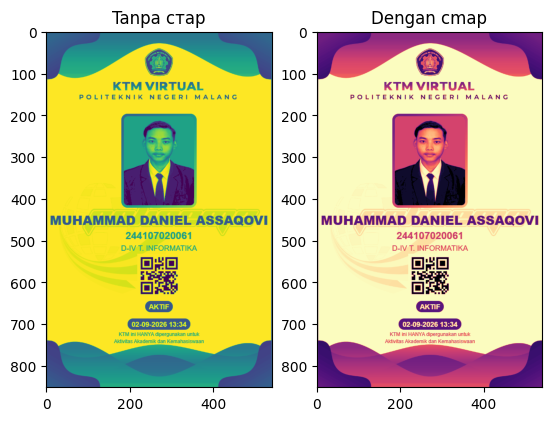

In [ ]:
img_gray = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png", cv2.IMREAD_GRAYSCALE)
# Tanpa стар
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa стар")
# Dengan cтар
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="magma")
plt.title("Dengan cmap")
plt.show()

4. Melakukan resizing

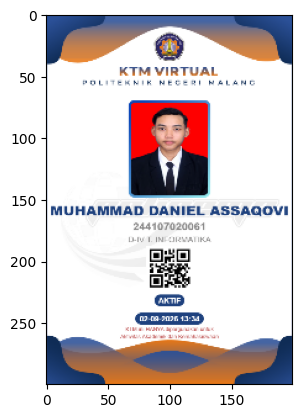

In [ ]:
img = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Konversi BGR ke RGB
imgRGBsmall = cv2.resize(imgRGB, (200,300))
plt.imshow(imgRGBsmall)

5. Melakukan Flipping

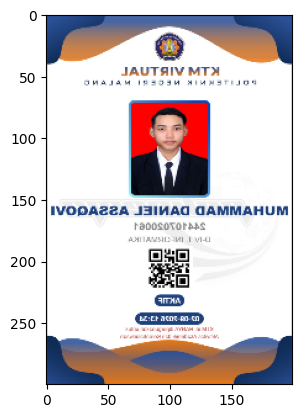

In [ ]:
img = cv2.imread("/content/drive/MyDrive/PCVK/contoh KTM.png")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Konversi BGR ke RGB
imgBalik = cv2.flip(imgRGBsmall, 1)
plt.imshow(imgBalik)

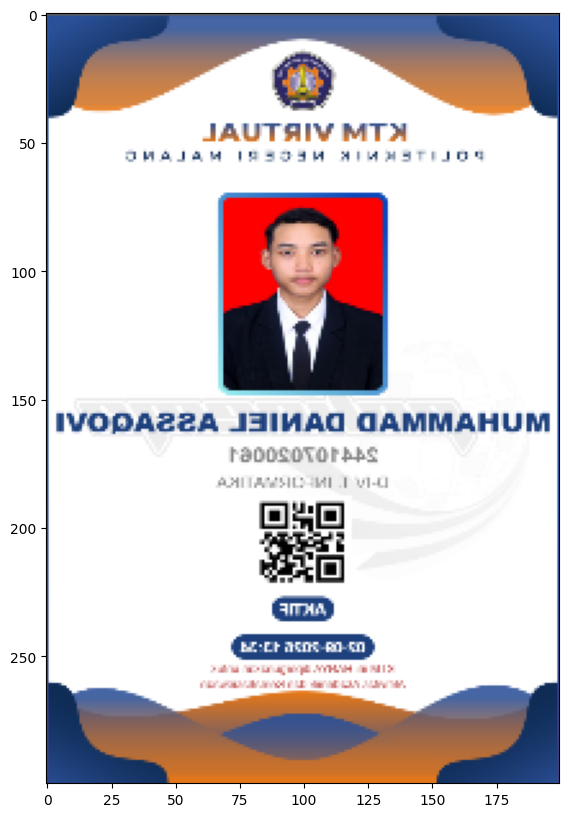

In [ ]:
imgBalik = cv2.flip(imgRGBsmall, 1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.imshow(imgBalik)



6. Geometri 2D dengan OpenCV

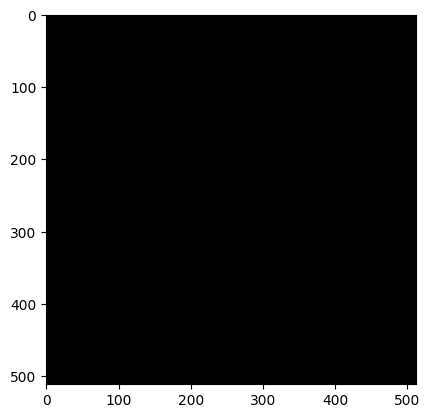

In [ ]:
black_img = np.zeros(shape=(512,512,3),dtype=np.int16)
plt.imshow(black_img)

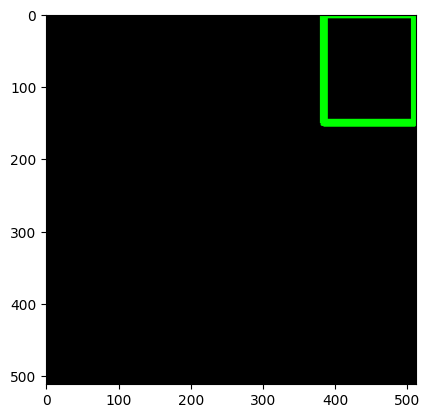

In [ ]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img, pt1 = (384, 0), pt2 = (510, 150), color=(0,255,0), thickness=10)
plt.imshow(black_img)

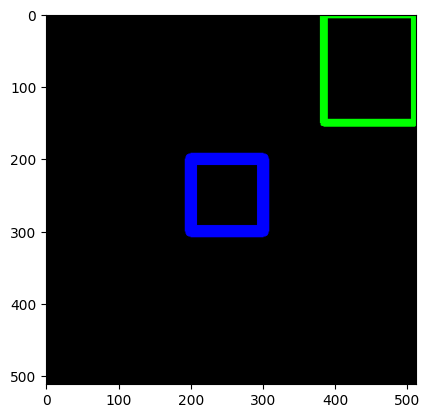

In [ ]:
cv.rectangle(black_img, pt1 = (200, 200), pt2 = (300, 300), color=(0,0,255), thickness=15)
plt.imshow(black_img)

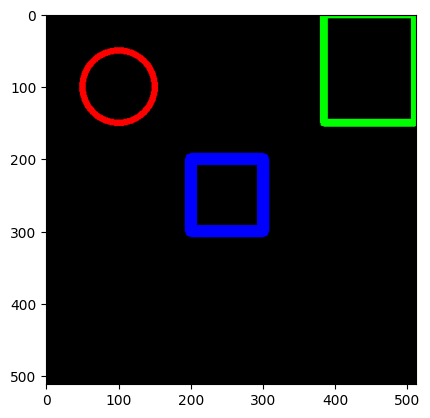

In [ ]:
cv.circle(black_img, center = (100, 100), radius = 50, color=(255,0,0), thickness=8)
plt.imshow(black_img)

 penambahan garis sesuai koordinat pt1 dan pt2

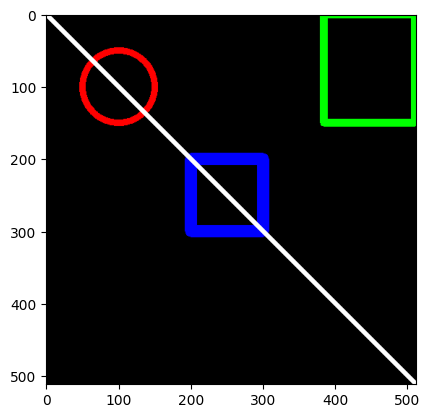

In [ ]:
cv.line(black_img, pt1 = (0, 0), pt2 = (512, 512), color=(255,255,255), thickness=5)
plt.imshow(black_img)

Penambahan text dengan font yang telah tertulis dengan ukuran yang sudah ditentukan.

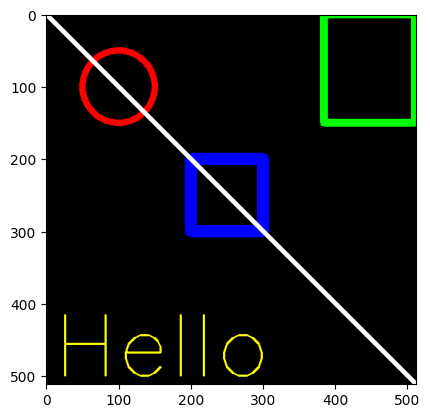

In [ ]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10,500), fontFace=font, fontScale=4,color=(255,255,0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

Pembuatan black image kembali dilakukan dengan tipe data int32

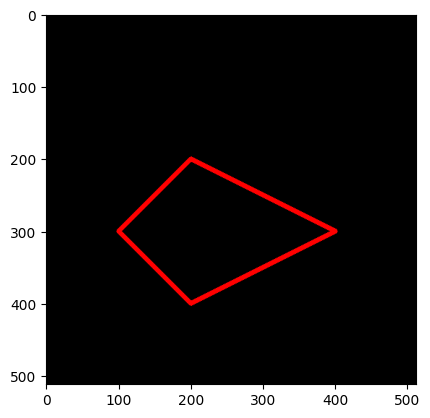

In [ ]:
black_img2 = np.zeros(shape=(512,512,3),dtype=np.int32)
plt.imshow(black_img2)

vertices = np.array([[100,300],[200,200],[400,300],[200,400]], dtype=np.int32)
pts = vertices.reshape((-1,1,2))  # nilai 2 menunjukkan tiap titik dibuat 1 baris x 2 kolom (x,y)

black_img2 = black_img2.astype(np.uint8)
cv.polylines(black_img2, [pts], isClosed=True, color=(255,0,0), thickness=5)
plt.imshow(black_img2)
plt.show()

**PERTANYAAN PRAKTIKUM D3**

**1. Perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib?**

Tanpa matplotlib (mis. cv2_imshow/cv2.imshow), citra ditampilkan langsung sebagai gambar utuh tanpa informasi sumbu/skala — hanya visual gambar. Dengan matplotlib (plt.imshow), citra ditampilkan sebagai plot lengkap dengan sumbu x-y (dalam satuan pixel), sehingga ukuran lebar-tinggi citra dan koordinat piksel tertentu bisa langsung dibaca dari grafik, serta bisa ditambah title, colormap, subplot, dsb. Perbedaan lain: matplotlib menampilkan array sesuai urutan channel data (misal BGR dari OpenCV akan tampak warnanya salah/terbalik jika tidak dikonversi ke RGB dulu), sedangkan cv2_imshow di Colab otomatis menampilkan sesuai BGR (default OpenCV) dengan benar.

**2. Perbedaan dan pengaruh pembuatan black image antara tipe data int16 dan int32?**

Keduanya sama-sama tipe integer bertanda (signed), bedanya kapasitas/rentang nilai: int16 menyimpan nilai -32.768 s.d 32.767 (2 byte per elemen), sedangkan int32 menyimpan rentang jauh lebih besar, -2.147.483.648 s.d 2.147.483.647 (4 byte per elemen). Untuk nilai piksel citra (0-255) keduanya sama-sama cukup dan secara visual hasil citra hitamnya identik. Pengaruhnya lebih ke penggunaan memori (int32 dua kali lebih besar dari int16) dan kecocokan dengan fungsi tertentu — beberapa fungsi OpenCV modern (mis. cv2.putText) mensyaratkan tipe data uint8 (CV_8U), sehingga array int16/int32 perlu dikonversi (.astype(np.uint8)) dulu sebelum dipakai fungsi tersebut, kalau tidak akan muncul error assertion.

**3. Kegunaan from google.colab.patches import cv2_imshow?**

Fungsi cv2.imshow() bawaan OpenCV membuka jendela GUI terpisah untuk menampilkan gambar, yang tidak didukung di lingkungan Google Colab (berjalan di server, tanpa display). cv2_imshow dari google.colab.patches adalah pengganti khusus Colab yang menampilkan citra langsung sebagai output sel notebook (mirip menampilkan gambar di web), sehingga citra hasil olahan OpenCV tetap bisa dilihat di Colab.

**4. Kegunaan from skimage import io?**

Modul io pada scikit-image (skimage.io) menyediakan fungsi untuk input/output citra, terutama io.imread() yang dapat membaca citra baik dari file lokal maupun langsung dari URL (link internet), lalu mengembalikannya sebagai array numpy siap diolah — inilah yang dipakai pada Langkah 2 (di M1_D2) untuk membaca citra dari daftar URL.



**TUGAS PRAKTIKUM D3**
Berdasarkan praktikum bagian 1 dan 2.

**1. Menggunakan figsize, apakah ukuran image pixelnya juga berubah?**

figsize hanya mengubah ukuran canvas/figure matplotlib saat ditampilkan (ukuran render di layar/di layout notebook) — bukan ukuran data citra itu sendiri. Array imgRGB.shape (jumlah pixel sebenarnya) tetap sama sebelum dan sesudah figsize diubah, dibuktikan pada sel di bawah.

Shape sebelum figsize: (852, 540, 3)


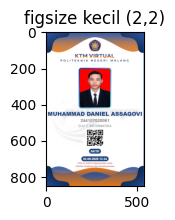

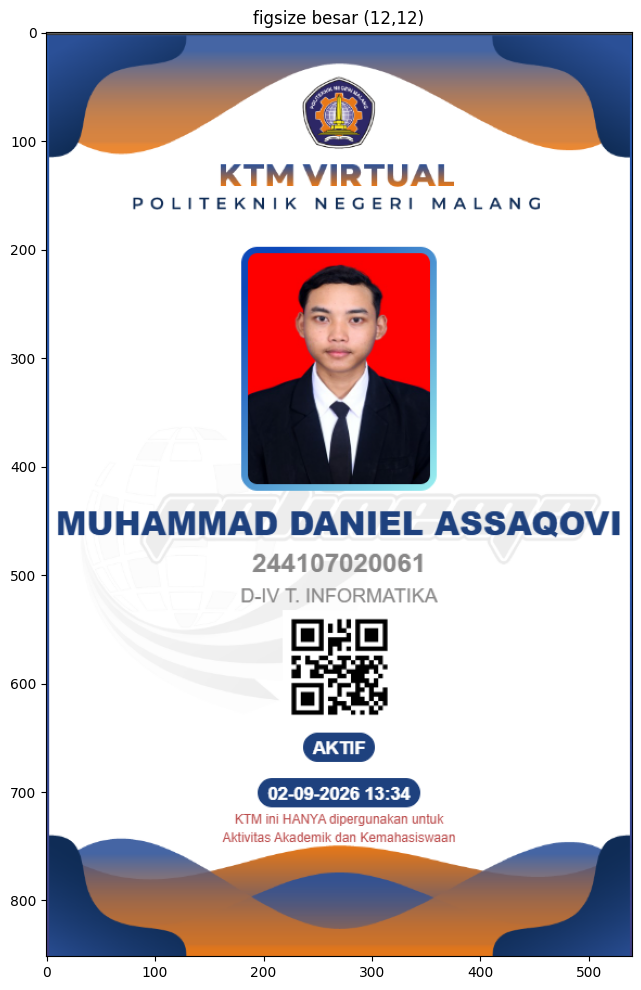

Shape sesudah figsize: (852, 540, 3) -> TIDAK berubah, hanya tampilan render yang membesar/mengecil


In [ ]:


print("Shape sebelum figsize:", imgRGB.shape)

fig = plt.figure(figsize=(2,2))
plt.imshow(imgRGB)
plt.title("figsize kecil (2,2)")
plt.show()

fig = plt.figure(figsize=(12,12))
plt.imshow(imgRGB)
plt.title("figsize besar (12,12)")
plt.show()

print("Shape sesudah figsize:", imgRGB.shape, "-> TIDAK berubah, hanya tampilan render yang membesar/mengecil")

**2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja!**

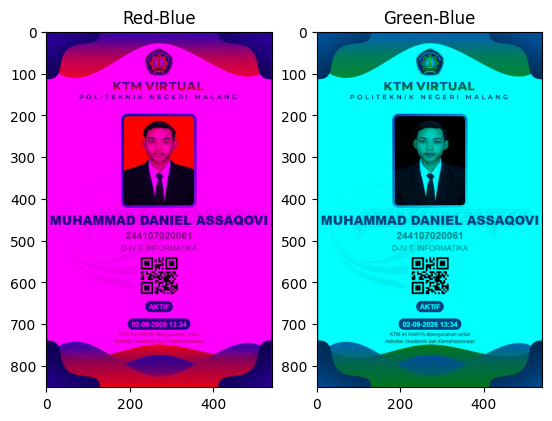

In [ ]:

R, G, B = cv.split(imgRGB)
zero = np.zeros_like(R)

img_RB = cv.merge([R, zero, B])   # hanya channel Red & Blue
img_GB = cv.merge([zero, G, B])   # hanya channel Green & Blue

plt.subplot(1,2,1); plt.imshow(img_RB); plt.title("Red-Blue")
plt.subplot(1,2,2); plt.imshow(img_GB); plt.title("Green-Blue")
plt.show()